# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error
)

# Questions:

- Can we predict whether a youth has used marijuana in the past year based on demographic and social factors?
- Can we predict the level of marijuana use (none, low, medium, high) among youth based on demographic and social factors?
- Can we predict alcohol use days among youth who reported using alcohol based on demographic and social factors?


# Data Processing

## Access data from github

In [ ]:
# Youth data
youth_url = "https://raw.githubusercontent.com/mendible/5322/main/Homework%201/youth_data.csv"
df = pd.read_csv(youth_url)

print("Shape:", df.shape)
print(df.columns.tolist())


Shape: (10561, 79)
['IRALCFY', 'IRMJFY', 'IRCIGFM', 'IRSMKLSS30N', 'IRALCFM', 'IRMJFM', 'IRCIGAGE', 'IRSMKLSSTRY', 'IRALCAGE', 'IRMJAGE', 'MRJFLAG', 'ALCFLAG', 'TOBFLAG', 'ALCYDAYS', 'MRJYDAYS', 'ALCMDAYS', 'MRJMDAYS', 'CIGMDAYS', 'SMKLSMDAYS', 'SCHFELT', 'TCHGJOB', 'AVGGRADE', 'STNDSCIG', 'STNDSMJ', 'STNDALC', 'STNDDNK', 'PARCHKHW', 'PARHLPHW', 'PRCHORE2', 'PRLMTTV2', 'PARLMTSN', 'PRGDJOB2', 'PRPROUD2', 'ARGUPAR', 'YOFIGHT2', 'YOGRPFT2', 'YOHGUN2', 'YOSELL2', 'YOSTOLE2', 'YOATTAK2', 'PRPKCIG2', 'PRMJEVR2', 'PRMJMO', 'PRALDLY2', 'YFLPKCG2', 'YFLTMRJ2', 'YFLMJMO', 'YFLADLY2', 'FRDPCIG2', 'FRDMEVR2', 'FRDMJMON', 'FRDADLY2', 'TALKPROB', 'PRTALK3', 'PRBSOLV2', 'PREVIOL2', 'PRVDRGO2', 'GRPCNSL2', 'PREGPGM2', 'YTHACT2', 'DRPRVME3', 'ANYEDUC3', 'RLGATTD', 'RLGIMPT', 'RLGDCSN', 'RLGFRND', 'IRSEX', 'NEWRACE2', 'HEALTH2', 'EDUSCHLGO', 'EDUSCHGRD2', 'EDUSKPCOM', 'IMOTHER', 'IFATHER', 'INCOME', 'GOVTPROG', 'POVERTY3', 'PDEN10', 'COUTYP4']


## Narrow columns down

In [ ]:
# Columns to keep
cols = [
    "MRJYDAYS",   # recoded marijuana frequency category
    "IRALCFY",    # alcohol days in past year

    # Predictors
    "IRSEX",
    "NEWRACE2",
    "EDUSCHGRD2",
    "SCHFELT",
    "STNDSMJ",
    "PRMJEVR2",
    "FRDMJMON",
    "POVERTY3"
]

df_model = df[cols].copy()

# Force numeric
for c in df_model.columns:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

print(df_model.shape)
df_model.head()

(10561, 10)


,MRJYDAYS,IRALCFY,IRSEX,NEWRACE2,EDUSCHGRD2,SCHFELT,STNDSMJ,PRMJEVR2,FRDMJMON,POVERTY3
0,6,991,1,7,3,1,2.0,1.0,1.0,1
1,3,991,2,1,6,2,1.0,2.0,2.0,1
2,6,1,1,6,2,1,2.0,1.0,1.0,3
3,6,991,2,7,2,2,2.0,1.0,1.0,2
4,6,991,1,1,5,1,2.0,2.0,1.0,3


## Create 3 targets

In [ ]:
# Binary target
# Can we predict whether a youth has used marijuana in the past year based on demographic and social factors?
# MRJYDAYS codes:
# 1-5 = some past year marijuana use
# 6 = non-user/no past year use
df_model["target_binary"] = np.where(
    df_model["MRJYDAYS"].between(1, 5), 1,
    np.where(df_model["MRJYDAYS"] == 6, 0, np.nan)
)

df_model["target_binary"].value_counts(dropna=False)

,count
target_binary,
0.0,9226
1.0,1335


In [ ]:
# Multi-class target
# Can we predict the level of marijuana use (none, low, medium, high) among youth based on demographic and social factors?
# Use MRJYDAYS, switch to a 4 level scale due to very high imbalance in 6 level
# Still an imbalance but not nearly as bad
def categorize_mj(x):
    if x == 6:
        return 0   # no use
    elif x in [1, 2]:
        return 1   # low use
    elif x in [3, 4]:
        return 2   # medium use
    elif x == 5:
        return 3   # high use
    else:
        return np.nan

df_model["target_multi"] = df_model["MRJYDAYS"].apply(categorize_mj)

df_model["target_multi"].value_counts(dropna=False)

,count
target_multi,
0,9226
1,769
2,441
3,125


In [ ]:
# Regression target
# Can we predict alcohol use days among youth who reported using alcohol based on demographic and social factors?
df_model["target_reg"] = df_model["IRALCFY"]

# Remove non-users and special codes
df_model.loc[df_model["target_reg"].isin([991, 993]), "target_reg"] = np.nan
df_model.loc[df_model["target_reg"] >= 994, "target_reg"] = np.nan

print(df_model["target_reg"].describe())

count    1865.000000
mean       22.414477
std        40.323468
min         1.000000
25%         2.000000
50%         5.000000
75%        24.000000
max       339.000000
Name: target_reg, dtype: float64


## Final dataset

In [ ]:
# Predictors
predictors = [
    "IRSEX",
    "NEWRACE2",
    "EDUSCHGRD2",
    "SCHFELT",
    "STNDSMJ",
    "PRMJEVR2",
    "FRDMJMON",
    "POVERTY3"
]

# Treat common high special codes in predictors as missing
for c in predictors:
    df_model.loc[df_model[c] >= 90, c] = np.nan

# Final clean modeling dataframe
df_clean = df_model.dropna(subset=predictors + ["target_binary", "target_multi", "target_reg"]).copy()

print("Clean shape:", df_clean.shape)

# Features
X = df_clean[predictors]

# Targets
y_binary = df_clean["target_binary"].astype(int)
y_multi = df_clean["target_multi"].astype(int)
y_reg = df_clean["target_reg"].astype(float)

df_clean.head()

Clean shape: (1598, 13)


,MRJYDAYS,IRALCFY,IRSEX,NEWRACE2,EDUSCHGRD2,SCHFELT,STNDSMJ,PRMJEVR2,FRDMJMON,POVERTY3,target_binary,target_multi,target_reg
2,6,1,1.0,6.0,2.0,1.0,2.0,1.0,1.0,3.0,0.0,0,1.0
12,6,36,1.0,1.0,8.0,1.0,2.0,1.0,1.0,1.0,0.0,0,36.0
16,6,1,2.0,7.0,5.0,1.0,2.0,1.0,1.0,1.0,0.0,0,1.0
29,6,2,1.0,1.0,8.0,1.0,1.0,1.0,1.0,1.0,0.0,0,2.0
34,6,3,1.0,1.0,6.0,1.0,2.0,2.0,1.0,3.0,0.0,0,3.0


# Model Work

## Train/test split

In [ ]:
# Binary with stratification
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Multi-class with stratification
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

# Regression no stratification
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

## Decision Tree

In [ ]:
# Binary
tree_b = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
tree_b.fit(X_train_b, y_train_b)
pred_b = tree_b.predict(X_test_b)

print("Decision Tree (Binary) Accuracy:", accuracy_score(y_test_b, pred_b))
print(confusion_matrix(y_test_b, pred_b))


# Multi-class
tree_m = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
tree_m.fit(X_train_m, y_train_m)
pred_m = tree_m.predict(X_test_m)

print("\nDecision Tree (Multi) Accuracy:", accuracy_score(y_test_m, pred_m))
print(confusion_matrix(y_test_m, pred_m))


# Regression
tree_r = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
tree_r.fit(X_train_r, y_train_r)
pred_r = tree_r.predict(X_test_r)

rmse_tree = np.sqrt(mean_squared_error(y_test_r, pred_r))
print("\nDecision Tree (Regression) RMSE:", rmse_tree)

Decision Tree (Binary) Accuracy: 0.74375
[[134  36]
 [ 46 104]]

Decision Tree (Multi) Accuracy: 0.590625
[[142  21   7   0]
 [ 31  28  21   0]
 [ 23  12  19   0]
 [  2   5   9   0]]

Decision Tree (Regression) RMSE: 36.87438546847387


 A shallow decision tree was used as a baseline model to balance interpretability and generalization. Limiting depth and increasing leaf size helps reduce overfitting, though performance is constrained compared to ensemble methods.

## Bagging (binary)

In [ ]:
# Hyperparameters were tuned by testing multiple values and selecting those that improved test performance while reducing overfitting
# Used shallow trees (depth=4, larger leaf size) to improve preformance
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=20),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train_b, y_train_b)
pred_bag = bag.predict(X_test_b)

print("Bagging Accuracy:", accuracy_score(y_test_b, pred_bag))
print(confusion_matrix(y_test_b, pred_bag))

print(classification_report(y_test_b, pred_bag))

Bagging Accuracy: 0.74375
[[126  44]
 [ 38 112]]
              precision    recall  f1-score   support

           0       0.77      0.74      0.75       170
           1       0.72      0.75      0.73       150

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



## Random forest (multi-class)

In [ ]:
# Increased trees and controlled depth to balance bias/variance tradeoff
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42
)

rf.fit(X_train_m, y_train_m)
pred_rf = rf.predict(X_test_m)

print("Random Forest Accuracy:", accuracy_score(y_test_m, pred_rf))
print(confusion_matrix(y_test_m, pred_rf))

print(classification_report(y_test_m, pred_rf, zero_division=0))

Random Forest Accuracy: 0.584375
[[154  11   5   0]
 [ 52  18  10   0]
 [ 31   8  15   0]
 [  6   4   6   0]]
              precision    recall  f1-score   support

           0       0.63      0.91      0.75       170
           1       0.44      0.23      0.30        80
           2       0.42      0.28      0.33        54
           3       0.00      0.00      0.00        16

    accuracy                           0.58       320
   macro avg       0.37      0.35      0.34       320
weighted avg       0.52      0.58      0.53       320



## Boosting (regression)

In [ ]:
boost = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
boost.fit(X_train_r, y_train_r)
pred_boost = boost.predict(X_test_r)

rmse_boost = np.sqrt(mean_squared_error(y_test_r, pred_boost))
print("Boosting RMSE:", rmse_boost)

Boosting RMSE: 36.250980169428246


## Model comparison:


- Bagging performed similarly to the decision tree
- Random forest did not improve and in fact had a worse performance over the decision tree for multi-class classification
- Boosting reduced regression error compared to decision tree
- Ensemble methods showed mixed results, with minimal or inconsistent improvements over the single decision tree

## Feature importance

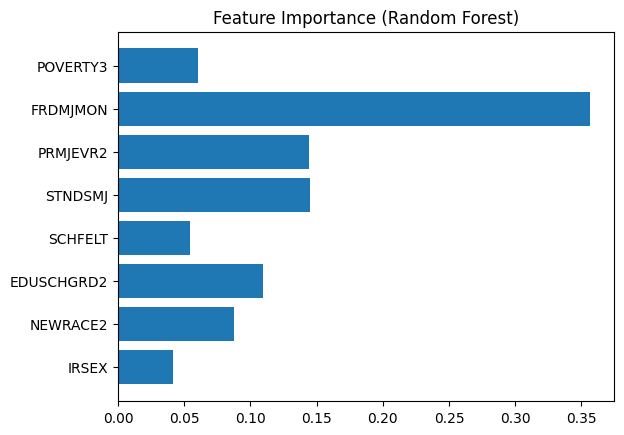

In [ ]:
# Random Forest importance
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

The feature importance plot shows that FRDMJMON is the strongest predictor of marijuana use, followed by variables related to peer influence and behavior (PRMJEVR2, STNDSMJ). Demographic factors like sex and poverty level have relatively smaller influence, suggesting social environment plays a larger role in predicting use.

## Tree visualization

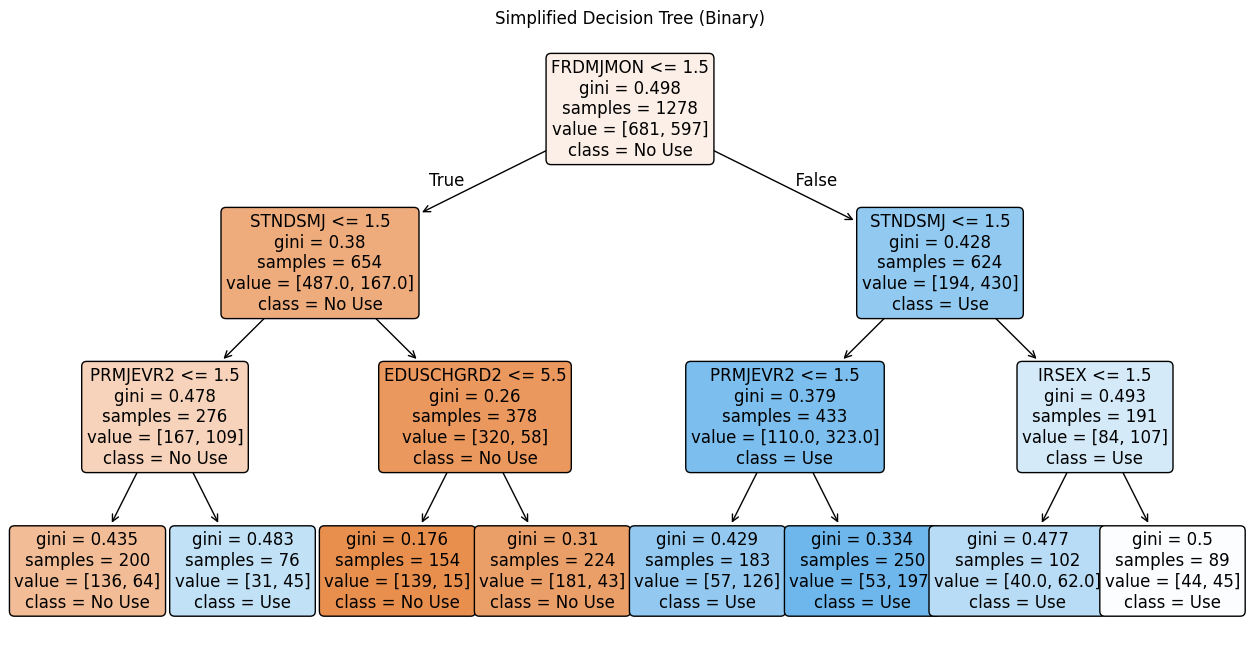

In [ ]:
display_tree = DecisionTreeClassifier(
    max_depth=3,          # key change
    min_samples_leaf=50,  # bigger leaves = cleaner
    random_state=42
)

display_tree.fit(X_train_b, y_train_b)

plt.figure(figsize=(16, 8))
plot_tree(
    display_tree,
    feature_names=X.columns,
    class_names=["No Use", "Use"],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Simplified Decision Tree (Binary)")
plt.show()

The simplified decision tree highlights the most important splits used to classify marijuana use. The first split on FRDMJMON indicates that peer marijuana use is the strongest factor, with additional splits on variables like STNDSMJ and PRMJEVR2 refining predictions.